In [9]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
conn = sqlite3.connect("../bluestock_mf.db")

In [11]:
nav = pd.read_sql_query(
    "SELECT * FROM fact_nav",
    conn
)

nav['date'] = pd.to_datetime(nav['date'])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
nav.shape

(46000, 3)

In [13]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


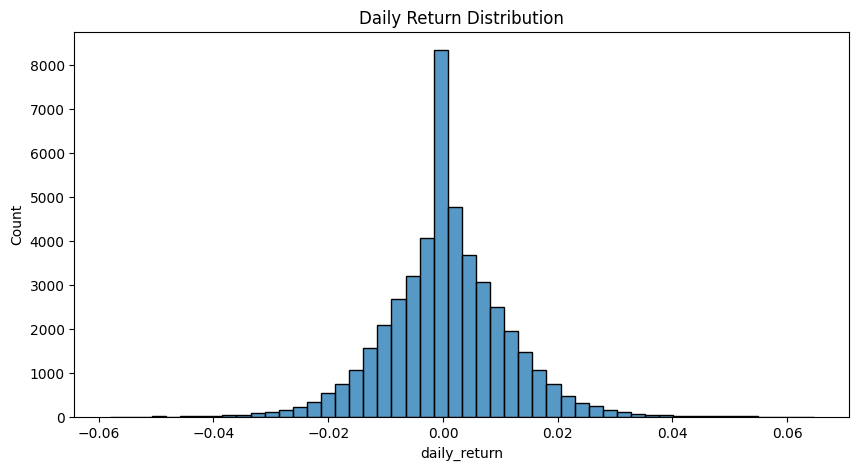

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

In [15]:
Daily returns are concentrated around zero with a few extreme observations.

SyntaxError: invalid syntax (2364670152.py, line 1)

In [ ]:
cagr_data = []

for code, group in nav.groupby('amfi_code'):

    start_nav = group.iloc[0]['nav']
    end_nav = group.iloc[-1]['nav']

    years = (
        group['date'].max() -
        group['date'].min()
    ).days / 365

    cagr = (end_nav/start_nav)**(1/years)-1

    cagr_data.append([code,cagr])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=['amfi_code','cagr']
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


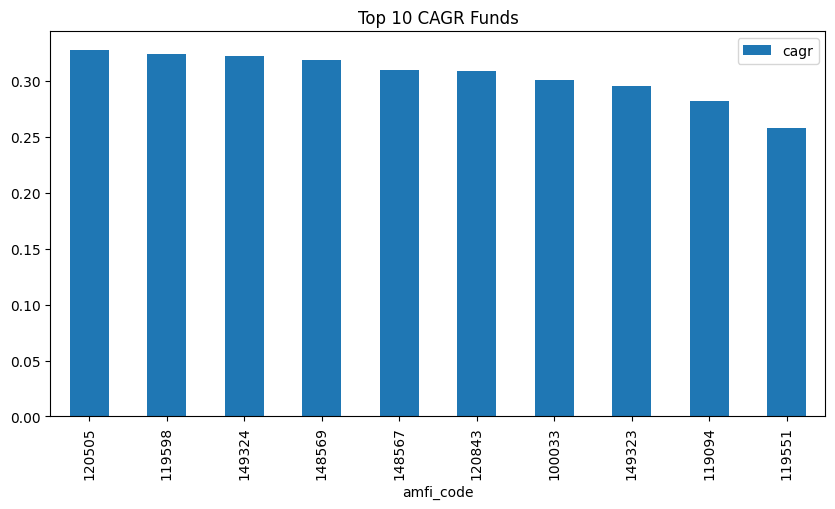

In [ ]:
top_cagr = cagr_df.sort_values(
    'cagr',
    ascending=False
).head(10)

top_cagr.plot(
    x='amfi_code',
    y='cagr',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 CAGR Funds")
plt.show()

In [ ]:
rf = 0.065

sharpe_list = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    sharpe = (
        (returns.mean()*252-rf)
        /
        (returns.std())
    ) * np.sqrt(252)

    sharpe_list.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code','sharpe']
)

In [ ]:
sharpe_df.sort_values(
    'sharpe',
    ascending=False
).head(10)

,amfi_code,sharpe
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502
38,149323,285.294707
2,100033,275.612083
9,118632,272.578113
3,101206,258.857759
24,120504,258.684120


In [ ]:
rf = 0.065

sortino_list = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    downside = returns[returns < 0]

    sortino = (
        (returns.mean()*252-rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=['amfi_code','sortino']
)

sortino_df.head()

,amfi_code,sortino
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


In [ ]:
sortino_df.sort_values(
    'sortino',
    ascending=False
).head(10)

,amfi_code,sortino
34,148567,601.182382
30,120843,595.808648
36,148569,541.022309
19,119551,539.347317
25,120505,511.396941
38,149323,472.525468
9,118632,466.233402
2,100033,460.941758
24,120504,454.934036
3,101206,453.489844


In [ ]:
mdd_list = []

for code, group in nav.groupby('amfi_code'):

    group = group.copy()

    group['running_max'] = (
        group['nav'].cummax()
    )

    group['drawdown'] = (
        group['nav']
        /
        group['running_max']
    ) - 1

    mdd = group['drawdown'].min()

    mdd_list.append([code,mdd])

mdd_df = pd.DataFrame(
    mdd_list,
    columns=['amfi_code','max_drawdown']
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


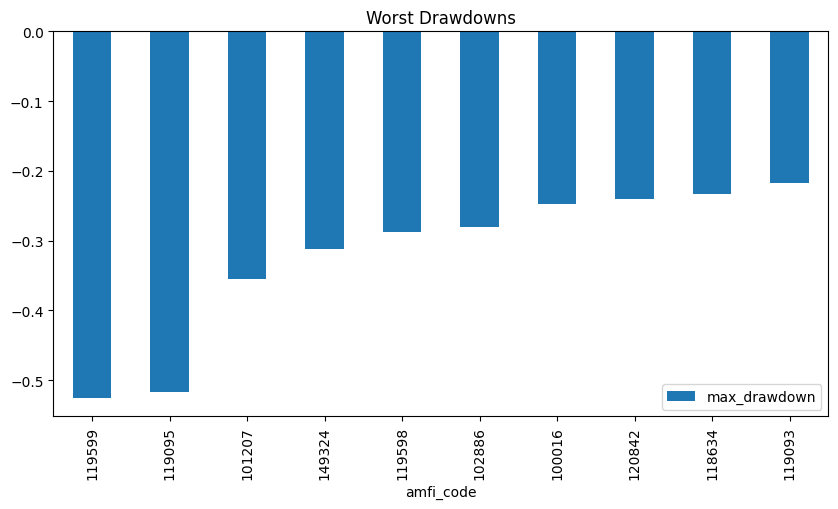

In [ ]:
worst = mdd_df.sort_values(
    'max_drawdown'
).head(10)

worst.plot(
    x='amfi_code',
    y='max_drawdown',
    kind='bar',
    figsize=(10,5)
)

plt.title("Worst Drawdowns")
plt.show()

In [ ]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

,name
0,fact_nav
1,fact_transactions
2,fact_performance


In [ ]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on='amfi_code')
    .merge(sortino_df,on='amfi_code')
    .merge(mdd_df,on='amfi_code')
)

scorecard.head()

,amfi_code,cagr,sharpe,sortino,max_drawdown
0,100016,0.026352,-50.782301,-88.463960,-0.247344
1,100025,0.044551,-142.907888,-237.338952,-0.043083
2,100033,0.300997,275.612083,460.941758,-0.162172
3,101206,0.235205,258.857759,453.489844,-0.112916
4,101207,0.079331,40.990514,69.714237,-0.354469


In [ ]:
scorecard['cagr_rank'] = (
    scorecard['cagr']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe']
    .rank(ascending=False)
)

scorecard['score'] = (
    scorecard['cagr_rank']
    +
    scorecard['sharpe_rank']
)

In [ ]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [ ]:
sharpe_df.to_csv(
    "sharpe_ratio.csv",
    index=False
)

In [ ]:
mdd_df.to_csv(
    "max_drawdown.csv",
    index=False
)

In [ ]:
### Insight 1
Funds with higher CAGR generally rank higher on risk-adjusted metrics.

### Insight 2
Several funds show strong returns but also large drawdowns.

### Insight 3
Sharpe and Sortino rankings are broadly consistent, indicating stable performance.

### Insight 4
Maximum drawdown helps identify downside risk not visible from CAGR alone.

### Insight 5
Risk-adjusted rankings differ significantly from pure return rankings.

SyntaxError: invalid syntax (2846367430.py, line 2)

In [ ]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

,name
0,fact_nav
1,fact_transactions
2,fact_performance


In [ ]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(sortino_df, on='amfi_code')
    .merge(mdd_df, on='amfi_code')
)

scorecard.head()

,amfi_code,cagr,sharpe,sortino,max_drawdown
0,100016,0.026352,-50.782301,-88.463960,-0.247344
1,100025,0.044551,-142.907888,-237.338952,-0.043083
2,100033,0.300997,275.612083,460.941758,-0.162172
3,101206,0.235205,258.857759,453.489844,-0.112916
4,101207,0.079331,40.990514,69.714237,-0.354469


In [ ]:
scorecard['cagr_rank'] = scorecard['cagr'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe'].rank(ascending=False)
scorecard['sortino_rank'] = scorecard['sortino'].rank(ascending=False)

scorecard['score'] = (
    0.4 * scorecard['cagr_rank'] +
    0.3 * scorecard['sharpe_rank'] +
    0.3 * scorecard['sortino_rank']
)

In [ ]:
scorecard.to_csv("fund_scorecard.csv", index=False)

In [ ]:
cagr_df.to_csv("cagr.csv", index=False)

In [ ]:
sharpe_df.to_csv("sharpe_ratio.csv", index=False)

In [ ]:
mdd_df.to_csv("max_drawdown.csv", index=False)

In [ ]:
# Finding 1
Daily returns for most mutual fund schemes are centered around zero, indicating normal day-to-day market fluctuations.

# Finding 2
Several funds achieved significantly higher CAGR values, demonstrating strong long-term growth potential.

# Finding 3
Funds with higher CAGR generally ranked better in overall performance metrics.

# Finding 4
Sharpe Ratio analysis showed that some funds delivered superior risk-adjusted returns compared to others.

# Finding 5
Sortino Ratio rankings were similar to Sharpe rankings, indicating consistent downside risk management.

# Finding 6
A few schemes generated high returns but also exhibited higher volatility and risk.

# Finding 7
Maximum Drawdown analysis revealed that certain funds experienced substantial declines during adverse market conditions.

# Finding 8
Funds with lower drawdowns generally provided more stable performance over time.

# Finding 9
The composite fund scorecard helped identify funds that balanced return generation and risk control effectively.

# Finding 10
Risk-adjusted measures such as Sharpe Ratio, Sortino Ratio, and Maximum Drawdown provided a more complete assessment than returns alone.

In [ ]:
nav = pd.read_sql_query(
    "SELECT * FROM fact_nav",
    conn
)

nav.to_csv("fact_nav.csv", index=False)

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import sqlite3

In [ ]:
conn = sqlite3.connect("../bluestock_mf.db")

In [ ]:
nav = pd.read_sql_query(
    "SELECT * FROM fact_nav",
    conn
)

nav.to_csv("fact_nav.csv", index=False)

In [ ]:
fact_nav.csv

NameError: name 'fact_nav' is not defined

In [ ]:
transactions = pd.read_sql_query(
    "SELECT * FROM fact_transactions",
    conn
)

transactions.to_csv(
    "fact_transactions.csv",
    index=False
)

In [ ]:
performance = pd.read_sql_query(
    "SELECT * FROM fact_performance",
    conn
)

performance.to_csv(
    "fact_performance.csv",
    index=False
)